# Model Inclusion

Let $G_1$, $G_2$ be two ADMGs. We aim to check if $\mathcal{M}(G_1)\subseteq \overline{\mathcal{M}(G_2)}$.

The key message of this demo is that a vertex cover problem on a large graph can often be reduced to an equivalent but simpler instance.

In [1]:
from utils import * 

## A minimal Example

**Require**:
* $n$: Number of Vertices
* $E_1$: Directed Edges for $G_1$
* $E_2$: Directed Edges for $G_2$
* $B_1$: Bidirected Edges for $G_1$
* $B_2$: Bidirected Edges for $G_2$

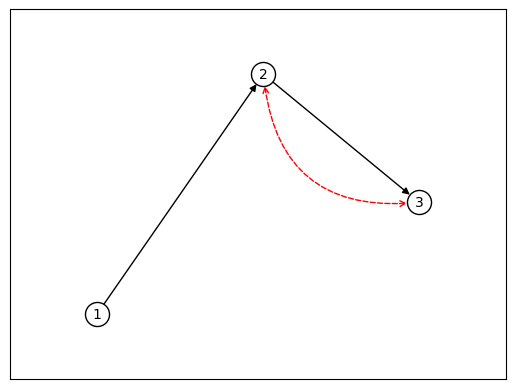

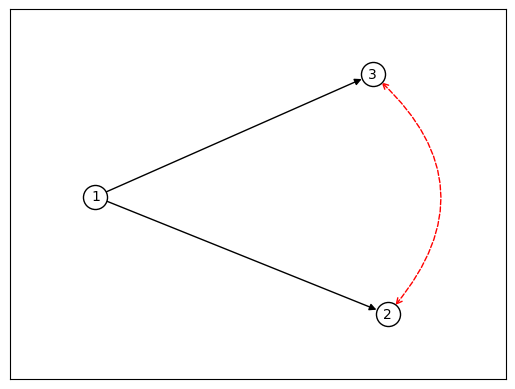

In [2]:
# Number of Vertices
n = 3

# Generate DAGs
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)

# Edge Sets
E1 = [(1,2),(2,3)]
E2 = [(1,2),(1,3)]
B1 = [(2,3)]
B2 = [(2,3)]

# Add Edges
G1.add_edges_from(E1)
G2.add_edges_from(E2)

# Plot the two ADMGs
plot_admg(G1, B1)
plot_admg(G2, B2)

### Check Model Inclusion

In [3]:
# This is our core function
# Check Model Inclusion
check_inclusion_full(G1, G2, B1, B2)

True

## A Much Larger Example?

The algorithm can handle fairly large graphs, if not get too unlucky.

Note that the original UAI algorithm is limited to graphs with $n < 15$.

Let's try it on two random ADMGs with 25 vertices and 20 bidirected edges.

Feel free to experiment with the number of vertices and confounders (bidirected edges).

### Generate two random ADMGs:

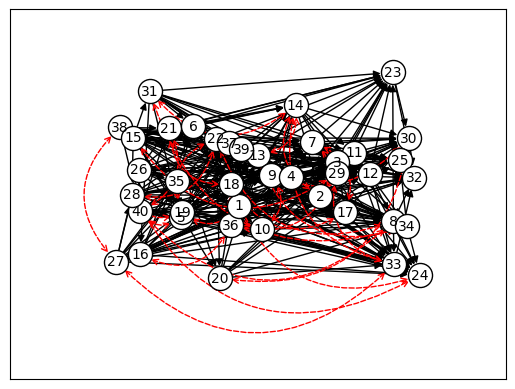

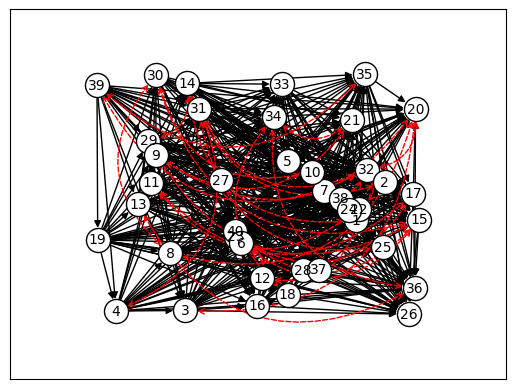

In [6]:
num_vertex = 40
num_confounding = 30

# Generate random graphs (DAGs) and confoundings
G1 = random_dag(num_vertex,random.random())
B1 = random_confounding(num_vertex,num_confounding)
G2 = random_dag(num_vertex,random.random())
B2 = random_confounding(num_vertex,num_confounding)

plot_admg(G1, B1)
plot_admg(G2, B2)

### Check Model Inclusion 

In [7]:
check_inclusion_full(G1, G2, B1, B2)

False

If it does not finish within 10 seconds, we have probably encountered an unlucky case. We will discuss these cases later.

## Our Key Ideas:

We argue that, in a considerable number of cases, the induced graph can be reduced effectively, such that only a single candidate vertex cover remains to be examined.

The following example illustrates this idea.

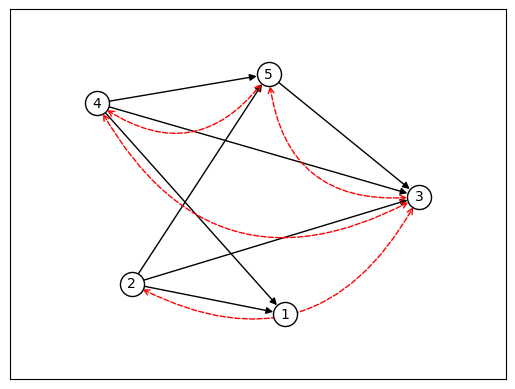

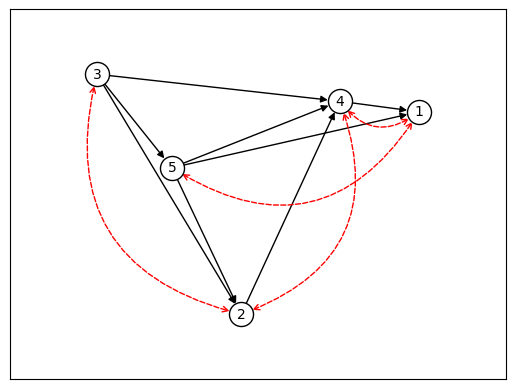

In [15]:
num_vertex = 5
num_confounding = 4

G1 = random_dag(num_vertex,random.random())
B1 = random_confounding(num_vertex,num_confounding)
G2 = random_dag(num_vertex,random.random())
B2 = random_confounding(num_vertex,num_confounding)

plot_admg(G1, B1)
plot_admg(G2, B2)

### How does the induced graph looks like?

The induced graph with vertices $V\times V$ has edge between $(u,w_1)$ to $(v,w_2)$ if $u\leftrightarrow v$ is not in $B_2$ and $w_1 \leftrightarrow w_2$ is in $B_1$.

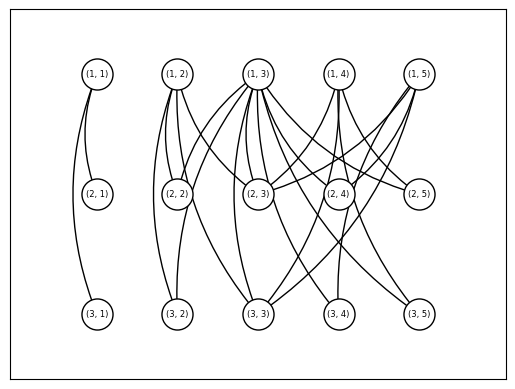

In [16]:
IG = induced_graph(V,B1,B2)
plot_induced(IG)

### Reduce the induced graph

*Problem:* We aim to determine whether there exists a vertex cover of the induced graph such that all path-rank constraints are satisfied.

In fact, the induced graph can often be reduced significantly.

We proceed as follows:

1) Remove all vertices that never break the path rank constraints, we will always take them into our vertex cover, that is $(V\times V)\setminus X$ with
    $$X=\bigcup_{i\in V}\{(i,j):j\in an_{G_1}(pa_{G_2}(i)\cup i)\}$$
2) Determine "red" nodes: vertices that always break the path rank constraints, we never take them into our vertex cover, that is
    $$S=\bigcup_{i\in V}\{(i,j)\in X:j\in an_{G_1}(i) \setminus an_{G_1}(pa_{G_2}(i))\}$$
3) "Blue" nodes: vertices that has an edge to "red" ones in this already reduced induced graph. They must be taken as it is necessary for any vertex cover.
4) Remove all "red" and "blue" vertices, and all edges using them.

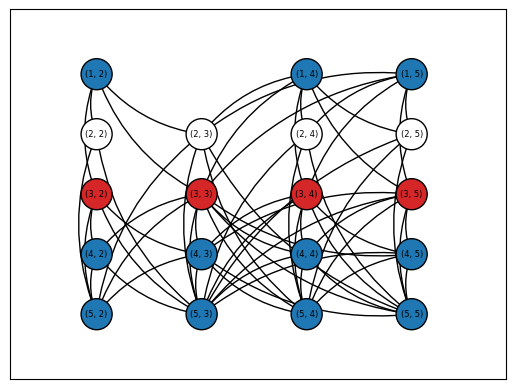

True

In [17]:
plot_auxiliary(G1,G2,B1,B2)

In the graph above, we have already removed the nodes that can always be included in the vertex cover.

Furthermore, the untakable nodes are marked in red, while the must-take nodes are marked in blue.

These colored nodes are deterministic: we already know whether they must be selected or not in any vertex cover satisfying all path-rank constraints.

After removing these deterministic nodes, we obtain the reduced graph shown below.

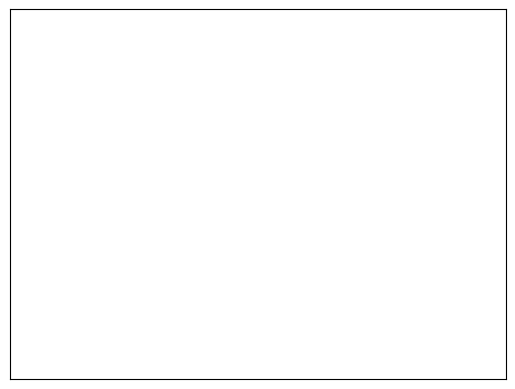

In [18]:
plot_reduced(G1,G2,B1,B2)

As illustrated above, the reduced graph is often empty.

In these cases, only a single vertex cover candidate remains to be checked, namely the set consisting of the blue nodes (must-take nodes) and the nodes that were previously removed as always takable.

Moreover, a vertex cover satisfying all path-rank constraints exists if and only if this set of blue nodes satisfies the path-rank constraints.

### What if the reduced graph is not empty?

This situation can occur. Even then, we can do better than an exhaustive search:

1. If the auxiliary graph contains an edge between two red (untakable) nodes, we can immediately conclude non-inclusion.
2. If the blue (must-take) nodes already violate the path-rank constraints, we can also conclude non-inclusion.
3. Otherwise, it suffices to check all inclusion-minimal vertex covers against the path-rank constraints.

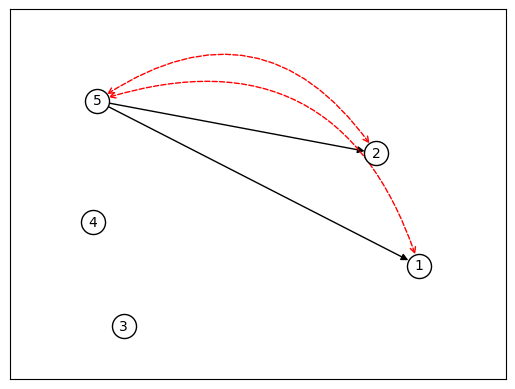

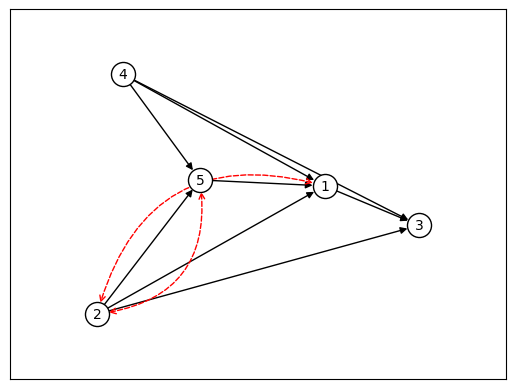

In [ ]:
n = 5
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
E1 = [(5, 1), (5, 2)]
E2 = [(4, 5), (4, 1), (4, 3), (2, 5), (2, 1), (2, 3), (5, 1), (1, 3)]
B1 = [(2, 5), (1, 5)]
B2 = [(1, 2), (2, 5)]
G1.add_edges_from(E1)
G2.add_edges_from(E2)
plot_admg(G1, B1)
plot_admg(G2, B2)

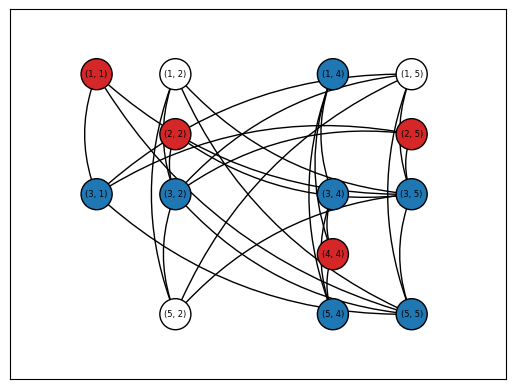

False

In [20]:
plot_auxiliary(G1,G2,B1,B2)

This time, the reduced graph is not empty.

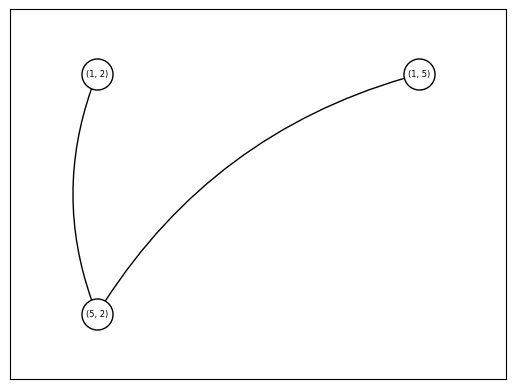

In [21]:
plot_reduced(G1,G2,B1,B2)

We enumerate all inclusion-minimal vertex covers:

In [22]:
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)
remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
IG_remain = IG_cleaned.subgraph(remain).copy()
IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))
P = powerset(IG_remain.nodes())
covers = inclusive_minimal_covers(IG_remain,P)
covers

[{(1, 2), (1, 5)}, {(5, 2)}]

There are only two inclusion-minimal vertex covers.

We verify the path-rank constraints for both of them.

In [23]:
for cover in covers:
    for i in V:
        X = list(get_j(unremovable_neighbors,i)) + list(get_j(cover,i))
        Y = list(G2.predecessors(i))
        if path_rank(G1, X, Y + [i]) != path_rank(G1, X, Y):
            break
    else:
        print(True)
        break
else:
    print(False)

True
